# Matrix Plots with Seaborn

`seaborn` is a plotting library built on top of matplotlib that gives us ready-made chart types like heatmaps and cluster maps for visualizing numeric data laid out in a grid, without drawing them piece by piece. `matplotlib.pyplot` is the lower-level plotting library seaborn sits on top of, and we import it alongside seaborn in case we need direct control over a plot.

**Usecase:** These two imports need to run first so that every plotting function used later in this notebook (`sns.heatmap`, `sns.clustermap`, etc.) is available to call.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Heat Maps

Heat maps are great for visualizing correlation matrices, pivot tables, and any 2D data where you want to see patterns through color coding.

### Loading the Flights Dataset

`sns.load_dataset('flights')` pulls in one of seaborn's built-in practice datasets and returns it as a pandas DataFrame, a table with rows and columns. This particular dataset records how many airline `passengers` flew in each `month` of each `year`.

**Usecase:** This dataset is used later to build a pivot table and heatmap, since it naturally has two categories (month and year) and one number (passengers), which is exactly the shape a matrix-style plot needs.

In [2]:
flights = sns.load_dataset('flights')
print("Flights dataset shape:", flights.shape)
flights.head()

Flights dataset shape: (144, 3)


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


### Loading the Tips Dataset

`sns.load_dataset("tips")` loads another one of seaborn's built-in sample datasets, this time restaurant bill data with columns like `total_bill`, `tip`, `sex`, `smoker`, `day`, `time`, and `size`.

**Usecase:** This dataset is used to build a correlation matrix, since it has several numeric columns (`total_bill`, `tip`, `size`) whose relationships we can compare in a heatmap and cluster map.

In [3]:
tips = sns.load_dataset("tips")
print("Tips dataset shape:", tips.shape)
tips.head()

Tips dataset shape: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Preparing Data for Correlation Matrix

Putting a list of column names inside double square brackets, like `tips[['total_bill','tip','size']]`, picks out just those columns from the DataFrame and returns them as a smaller DataFrame, instead of a single column.

**Usecase:** Here it narrows `tips` down to only the numeric columns we actually want to compare, dropping text columns like `sex` or `day` that wouldn't make sense in a correlation calculation.

In [4]:
tipscorr = tips[['total_bill', 'tip', 'size']]
print("Selected numeric columns:")
tipscorr.head()

Selected numeric columns:


,total_bill,tip,size
0,16.99,1.01,2
1,10.34,1.66,3
2,21.01,3.50,3
3,23.68,3.31,2
4,24.59,3.61,4


### Computing Correlation Matrix

`.corr()` is a pandas method that looks at every pair of numeric columns in a DataFrame and calculates how strongly they move together, giving a number between -1 and 1 for each pair. A value near 1 means the two columns tend to go up together, near -1 means one goes up as the other goes down, and near 0 means they're not really related.

**Usecase:** Running `tipscorr.corr()` produces the correlation matrix between `total_bill`, `tip`, and `size` that gets fed straight into the heatmap and cluster map in the next steps.

In [5]:
correlation_matrix = tipscorr.corr()
print("Correlation Matrix:")
correlation_matrix

Correlation Matrix:


,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


### Creating a Heatmap

`sns.heatmap(data, annot=True)` takes a grid of numbers (like a correlation matrix) and colors each cell based on its value, so bigger or smaller numbers stand out visually at a glance. `annot=True` additionally writes the actual number inside each colored cell instead of leaving you to guess it from the color alone.

**Usecase:** This turns the `total_bill`/`tip`/`size` correlation numbers from the previous cell into a picture, making it easy to instantly spot which pair of columns is most strongly related just by looking for the brightest cell.

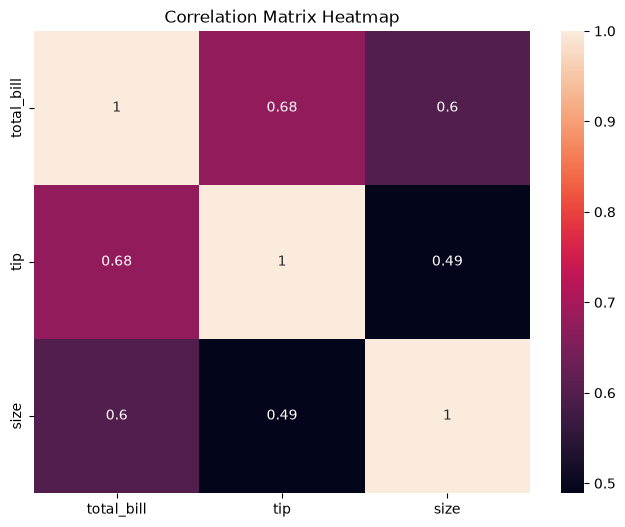

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True)
plt.title('Correlation Matrix Heatmap')
plt.show()

## Cluster Maps

`sns.clustermap(data)` draws the same kind of colored grid as a heatmap, but it also groups rows and columns that behave similarly next to each other, and draws small tree-like diagrams (dendrograms) along the edges showing how that grouping was done.

**Usecase:** Applied to the same `total_bill`/`tip`/`size` correlation matrix, this reorders the columns so the most similar ones sit next to each other, which can make patterns easier to spot than in a plain heatmap once there are more columns involved.

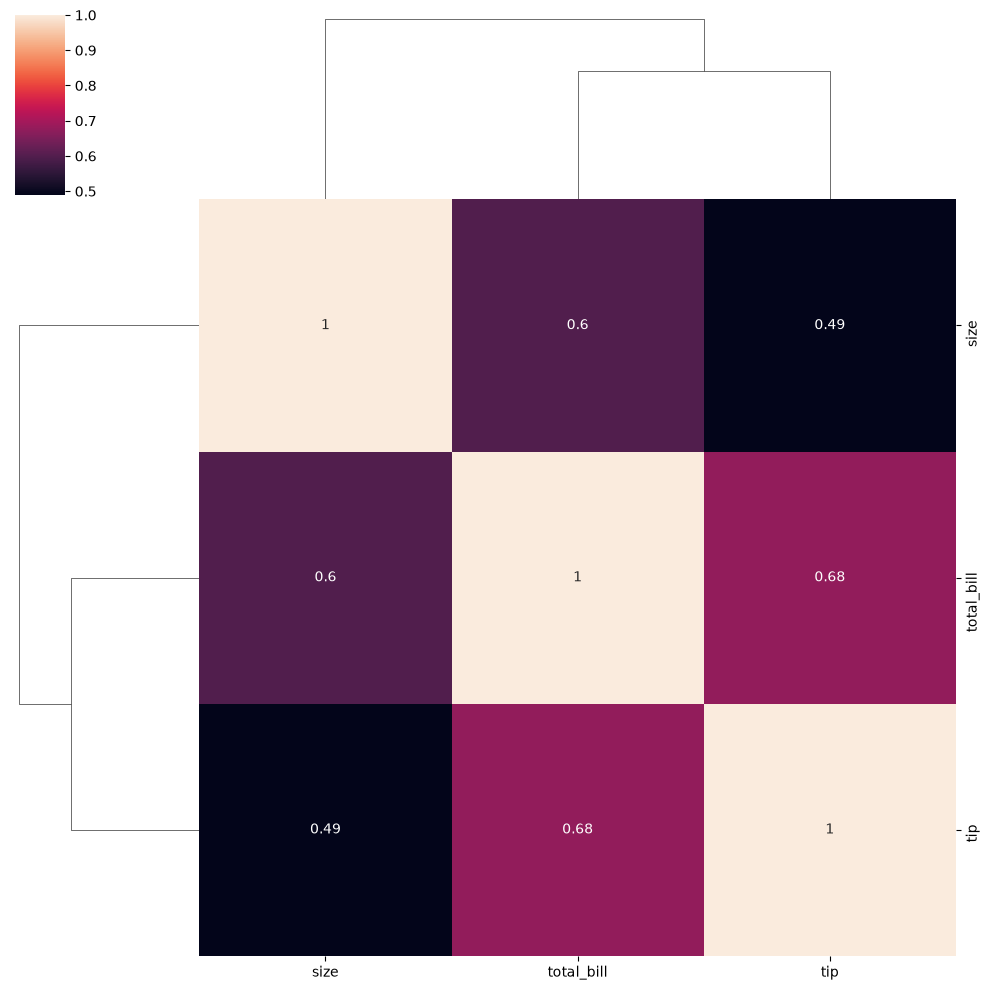

In [13]:
sns.clustermap(correlation_matrix, annot=True)
plt.show()

## Pivot Table Heat Maps

Let's create a more complex heatmap using the flights dataset by creating a pivot table first.

### Creating a Pivot Table

`.pivot_table(values=..., index=..., columns=...)` is a pandas method that reshapes a long table into a grid. It takes one column to fill the rows (`index`), another to fill the columns (`columns`), and a third column of numbers to fill in the grid cells (`values`).

**Usecase:** Here it reshapes the `flights` data so that `month` becomes the rows, `year` becomes the columns, and each cell holds the `passengers` count for that month-year combination, turning it into a grid a heatmap can be drawn on.

In [8]:
pvtflight = flights.pivot_table(values='passengers', index='month', columns='year')
print("Pivot table shape:", pvtflight.shape)
pvtflight

Pivot table shape: (12, 12)


year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112.0,115.0,145.0,171.0,196.0,204.0,242.0,284.0,315.0,340.0,360.0,417.0
Feb,118.0,126.0,150.0,180.0,196.0,188.0,233.0,277.0,301.0,318.0,342.0,391.0
Mar,132.0,141.0,178.0,193.0,236.0,235.0,267.0,317.0,356.0,362.0,406.0,419.0
Apr,129.0,135.0,163.0,181.0,235.0,227.0,269.0,313.0,348.0,348.0,396.0,461.0
May,121.0,125.0,172.0,183.0,229.0,234.0,270.0,318.0,355.0,363.0,420.0,472.0
Jun,135.0,149.0,178.0,218.0,243.0,264.0,315.0,374.0,422.0,435.0,472.0,535.0
Jul,148.0,170.0,199.0,230.0,264.0,302.0,364.0,413.0,465.0,491.0,548.0,622.0
Aug,148.0,170.0,199.0,242.0,272.0,293.0,347.0,405.0,467.0,505.0,559.0,606.0
Sep,136.0,158.0,184.0,209.0,237.0,259.0,312.0,355.0,404.0,404.0,463.0,508.0


### Heatmap of Pivot Table

This is the same `sns.heatmap()` function as before, but this time it's given the `pvtflight` pivot table directly instead of a correlation matrix, and without `annot=True` so the numbers aren't printed inside the cells.

**Usecase:** Coloring the grid this way makes it easy to spot patterns over time at a glance, such as passenger numbers being consistently higher in the brighter summer months (like July and August) and generally increasing across the years from left to right.

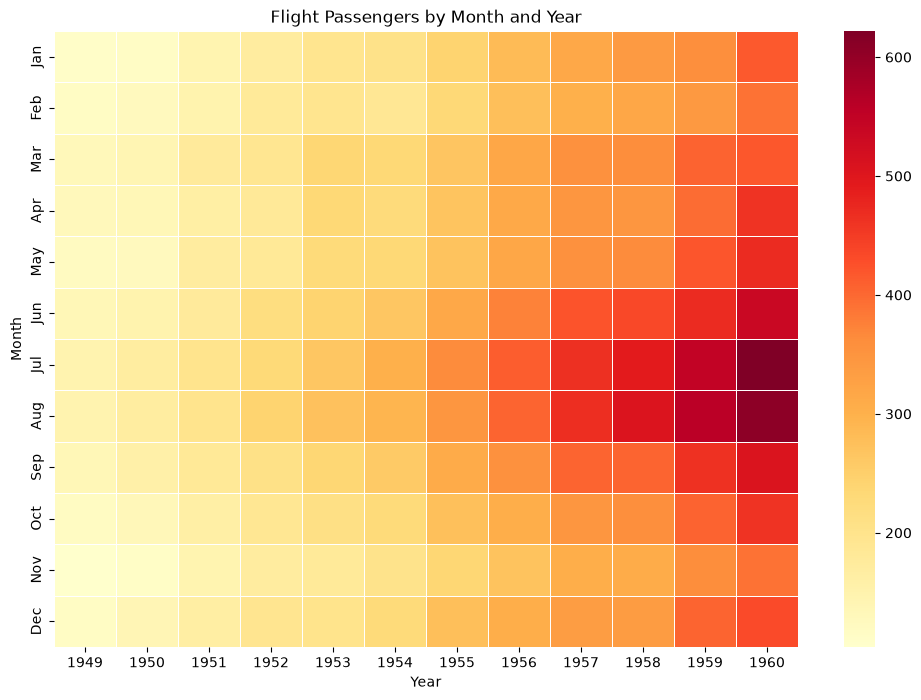

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(pvtflight, cmap='YlOrRd', linewidths=0.5)
plt.title('Flight Passengers by Month and Year')
plt.xlabel('Year')
plt.ylabel('Month')
plt.show()

## Summary

In this notebook, we explored matrix plots using seaborn:

1. **Heatmaps**: Visualize 2D data through color coding
   - Correlation matrices
   - Pivot tables
   - With and without annotations

2. **Clustermaps**: Heatmaps with hierarchical clustering
   - Automatically groups similar rows/columns
   - Shows dendrograms for clustering relationships

3. **Pivot Table Heatmaps**: Transform long data into matrix format
   - Useful for time series data
   - Great for spotting temporal patterns

These visualizations are essential for exploring relationships in multidimensional data and identifying patterns that might not be obvious in raw numbers.